# 전기차 가격 예측

모델별 예측값을 분리해 비교하고, 학습 구간 내부 3-fold 검증으로 모델을 선택한 뒤 미사용 20% 홀드아웃을 평가합니다. 전처리는 각 학습 fold에서만 학습합니다. 제조사·모델·주행거리는 임의 p-value 삭제 없이 유지합니다. 배터리 결측은 학습 자료의 중앙값과 결측 지시자로 처리합니다. 무작위 분리는 제공 데이터 내 평가이며 신규 차종·미래 시점 일반화를 보장하지 않습니다.

원본 CSV는 변경하지 않습니다. 실행 결과는 `outputs/`에 저장됩니다.

In [1]:
%matplotlib inline
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from IPython.display import display
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
fonts = {f.name for f in font_manager.fontManager.ttflist}
for font in ['Malgun Gothic', 'AppleGothic', 'NanumGothic']:
    if font in fonts:
        plt.rcParams['font.family'] = font
        break
plt.rcParams['axes.unicode_minus'] = False
OUT = Path('outputs')
OUT.mkdir(exist_ok=True)
SEED = 2026

def preprocessing(frame):
    categorical = frame.select_dtypes(include=['object', 'string', 'category']).columns.tolist()
    numerical = [c for c in frame if c not in categorical]
    return ColumnTransformer([
        ('num', SimpleImputer(strategy='median', add_indicator=True), numerical),
        ('cat', Pipeline([('fill', SimpleImputer(strategy='constant', fill_value='Unknown')),
                          ('encode', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), categorical)
    ])

def save_submission(sample, ids, target, prediction):
    assert list(sample.columns) == [ids.name, target], '제출 열 확인 필요'
    assert len(ids) == len(prediction) == len(sample)
    assert sample[ids.name].astype(str).tolist() == ids.astype(str).tolist(), '제출 ID 순서 불일치'
    assert np.isfinite(prediction).all()
    result = sample.copy()
    result[target] = prediction
    result.to_csv(OUT / 'submission.csv', index=False)
    return result



## 데이터와 검증 설계

In [2]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
sample = pd.read_csv('sample_submission.csv')
TARGET = '가격(백만원)'
assert train['ID'].is_unique and test['ID'].is_unique
assert train[TARGET].notna().all()
X = train.drop(columns=['ID', TARGET])
y = train[TARGET]
assert set(X.columns) == set(test.columns) - {'ID'}
X_test = test[X.columns]
display(train.isna().sum().rename('결측 수').to_frame())
print('학습 / 제출:', train.shape, test.shape)
X_fit, X_hold, y_fit, y_hold = train_test_split(X, y, test_size=.2, random_state=SEED)
cv = KFold(n_splits=3, shuffle=True, random_state=SEED)
# 최종 홀드아웃의 타깃은 모델 선택에 사용하지 않는다.
models = {
    'Median baseline': DummyRegressor(strategy='median'),
    'Random Forest': RandomForestRegressor(n_estimators=150, min_samples_leaf=2, random_state=SEED, n_jobs=4),
    'XGBoost': XGBRegressor(n_estimators=250, max_depth=5, learning_rate=.05, random_state=SEED, n_jobs=4),
    'LightGBM': LGBMRegressor(n_estimators=250, learning_rate=.05, random_state=SEED, n_jobs=4, verbosity=-1),
}
rows = []
for name, model in models.items():
    pipe = Pipeline([('prep', preprocessing(X)), ('model', model)])
    result = cross_validate(pipe, X_fit, y_fit, cv=cv, scoring='neg_root_mean_squared_error', n_jobs=1)
    rows.append({'model': name, 'cv_rmse_mean': -result['test_score'].mean(),
                 'cv_rmse_std': result['test_score'].std()})
scores = pd.DataFrame(rows).sort_values('cv_rmse_mean')
display(scores)
scores.to_csv(OUT / 'model_comparison.csv', index=False)


,결측 수
ID,0
제조사,0
모델,0
차량상태,0
배터리용량,2711
구동방식,0
주행거리(km),0
보증기간(년),0
사고이력,0
연식(년),0


학습 / 제출: (7497, 11) (846, 10)


,model,cv_rmse_mean,cv_rmse_std
3,LightGBM,1.396176,0.040093
2,XGBoost,1.459498,0.068116
1,Random Forest,1.467834,0.053465
0,Median baseline,37.300388,0.929883


## 최종 홀드아웃과 오차 분석

{
  "selected_model": "LightGBM",
  "holdout_rmse": 1.3855937601175952,
  "holdout_mae": 0.7250260426863262,
  "baseline_rmse": 36.89138932867669,
  "unit": "백만원",
  "split_seed": 2026
}


,n,mae
모델,,
IONIQ,29,5.309079
TayCT,65,3.023746
Tay,69,2.177341
iX,67,0.580623
MS,55,0.573964
MX,57,0.561648
ID4,122,0.559943
Niro,81,0.547840
Soul,62,0.528343


,n,mae
차량상태,,
Brand New,705,0.827695
Pre-Owned,432,0.655533
Nearly New,363,0.608331


,n,mae
price_band,,
"(120.0, inf]",146,1.434401
"(80.0, 120.0]",242,0.997938
"(0.0, 40.0]",567,0.680325
"(40.0, 80.0]",545,0.460314


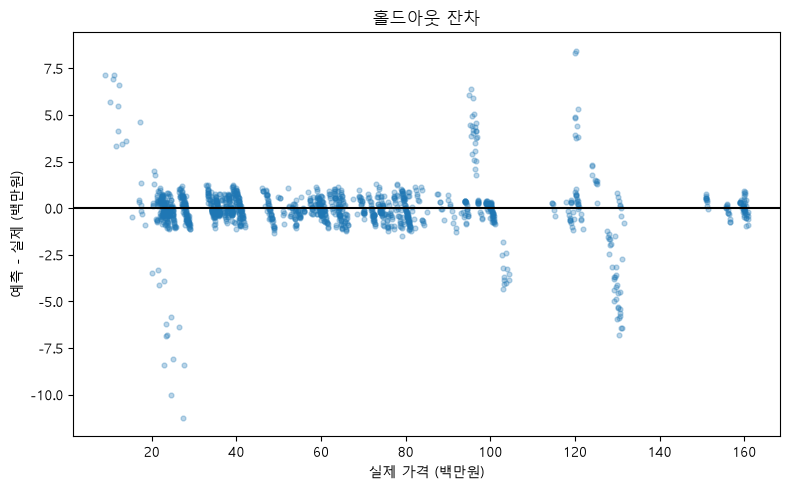

In [3]:
best_name = scores.iloc[0]['model']
best = Pipeline([('prep', preprocessing(X)), ('model', models[best_name])])
best.fit(X_fit, y_fit)
prediction = best.predict(X_hold)
baseline = np.full(len(y_hold), y_fit.median())
metrics = {'selected_model': best_name, 'holdout_rmse': root_mean_squared_error(y_hold, prediction),
           'holdout_mae': mean_absolute_error(y_hold, prediction),
           'baseline_rmse': root_mean_squared_error(y_hold, baseline),
           'unit': '백만원', 'split_seed': SEED}
print(json.dumps(metrics, ensure_ascii=False, indent=2))
(OUT / 'metrics.json').write_text(json.dumps(metrics, ensure_ascii=False, indent=2), encoding='utf-8')
errors = X_hold[['모델', '차량상태']].copy()
errors['actual'] = y_hold
errors['prediction'] = prediction
errors['absolute_error'] = abs(y_hold - prediction)
errors['price_band'] = pd.cut(y_hold, [0, 40, 80, 120, np.inf])
for group in ['모델', '차량상태', 'price_band']:
    summary = errors.groupby(group, observed=True).agg(n=('actual', 'size'), mae=('absolute_error', 'mean'))
    display(summary.sort_values('mae', ascending=False))
    summary.to_csv(OUT / f'errors_{group}.csv')
errors.to_csv(OUT / 'holdout_predictions.csv', index=False)
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(y_hold, prediction - y_hold, alpha=.3, s=12)
ax.axhline(0, color='black')
ax.set(xlabel='실제 가격 (백만원)', ylabel='예측 - 실제 (백만원)', title='홀드아웃 잔차')
fig.tight_layout(); fig.savefig(OUT / 'residuals.png'); plt.show(); plt.close(fig)


## 전체 학습과 제출

In [4]:
best.fit(X, y)
submission = save_submission(sample, test['ID'], TARGET, best.predict(X_test))
display(submission.head())


,ID,가격(백만원)
0,TEST_000,130.712706
1,TEST_001,79.996731
2,TEST_002,64.865661
3,TEST_003,34.825999
4,TEST_004,47.915585
